<a href="https://colab.research.google.com/github/SahelKherad/3-story-benchmark-transformer/blob/main/1405_02_14(2_sensor_9_state_(Importance_sensor_in__class).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import scipy.io
from scipy.io.matlab._mio5_params import mat_struct
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
!ls "/content/drive/My Drive/ASCE"

shm01a.mat  shm03a.mat	shm05a.mat  shm07a.mat	shm09a.mat
shm02a.mat  shm04a.mat	shm06a.mat  shm08a.mat


In [ ]:
def load_mat(path):
    mat = scipy.io.loadmat(path, squeeze_me=True, struct_as_record=False)
    raw = mat.get('dasy')
    if isinstance(raw, mat_struct):
        channels = []
        for f in raw._fieldnames:
            arr = getattr(raw, f)
            channels.append(np.asarray(arr).reshape(-1))
        data = np.stack(channels, axis=1)  # (n_samples, n_channels)
    else:
        raise ValueError("Unexpected MAT structure. 'dasy' not a struct.")
    return data  # float64 by default

base_dir = '/content/drive/MyDrive/ASCE/'
state_files = {
    1: 'shm01a.mat', 2: 'shm02a.mat', 3: 'shm03a.mat',
    4: 'shm04a.mat', 5: 'shm05a.mat', 6: 'shm06a.mat',
    7: 'shm07a.mat', 8: 'shm08a.mat', 9: 'shm09a.mat',
}
# label_to_class_id: 1..9 -> 0..8
label_to_cid = {lab: i for i, lab in enumerate(sorted(state_files.keys()))}

scenario_data = {}   # cid -> np.ndarray [N, C]
for lab, fname in state_files.items():
    x = load_mat(os.path.join(base_dir, fname)).astype(np.float32)
    scenario_data[label_to_cid[lab]] = x
    print(fname, x.shape)
print(scenario_data[0][:,:].shape)
print(scenario_data[0][:,4].shape)
print(scenario_data[4][:,4].shape)
    # print(fname, x.shape)

shm01a.mat (60000, 16)
shm02a.mat (60000, 16)
shm03a.mat (60000, 16)
shm04a.mat (60000, 16)
shm05a.mat (60000, 16)
shm06a.mat (45568, 16)
shm07a.mat (180000, 16)
shm08a.mat (180000, 16)
shm09a.mat (180000, 16)
(60000, 16)
(60000,)
(60000,)


In [ ]:
# 4) Choose the 5 scenarios and the 4 sensors you care about
chosen_scenario = {
    "healthy": 0,    # shm01a.mat
    "dam1":    1,    # shm02a.mat
    "dam2":    2,    # shm03a.mat
    "dam3":    3,    # shm04a.mat
    "dam4":    4,    # shm05a.mat
    "dam5":    5,    # shm06a.mat
    "dam6":    6,    # shm07a.mat
    "dam7":    7,    # shm08a.mat
    "dam8":    8,    # shm09a.mat
   }
sensor_cols = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14]


In [ ]:
win = 512
stride = 512

In [ ]:
def select_sensors(arr, cols):
  return arr[:, cols]

In [ ]:
# sensor1=10000*select_sensors(scenario_data[0], sensor_cols)
# sensor2=10000*select_sensors(scenario_data[1], sensor_cols)
# print(sensor1)
# print(sensor2)

In [ ]:
def split_time_based(X, train_ratio=0.6, val_ratio=0.2):
    n = len(X)
    m = int(train_ratio * n)
    l = int(val_ratio * n)
    train = X[:m]
    val   = X[m:m+l]
    test  = X[m+l:]
    return train, val, test

def build_split(scenario_data, chosen_scenario, sensor_cols):
  splits = {}
  for name, cid in chosen_scenario.items():
    # print(name, cid)
    data = select_sensors(scenario_data[cid], sensor_cols)
    train, val, test = split_time_based(data, train_ratio = 0.6, val_ratio = 0.2)
    splits[name] = (train, val, test)
  return splits


In [ ]:
splits = build_split(scenario_data, chosen_scenario, sensor_cols)

In [ ]:
train_0, val_0, test_0 = splits['healthy']
train_1, val_1, test_1 = splits['dam1']
train_2, val_2, test_2 = splits['dam2']
train_3, val_3, test_3 = splits['dam3']
train_4, val_4, test_4 = splits['dam4']
train_5, val_5, test_5 = splits['dam5']
train_6, val_6, test_6 = splits['dam6']
train_7, val_7, test_7 = splits['dam7']
train_8, val_8, test_8 = splits['dam8']

print((train_0.shape, val_0.shape, test_0.shape))
print((train_1.shape, val_1.shape, test_1.shape))
print((train_2.shape, val_2.shape, test_2.shape))
print((train_3.shape, val_3.shape, test_3.shape))
print((train_4.shape, val_4.shape, test_4.shape))
print((train_5.shape, val_5.shape, test_5.shape))
print((train_6.shape, val_6.shape, test_6.shape))
print((train_7.shape, val_7.shape, test_7.shape))
print((train_8.shape, val_8.shape, test_8.shape))

((36000, 15), (12000, 15), (12000, 15))
((36000, 15), (12000, 15), (12000, 15))
((36000, 15), (12000, 15), (12000, 15))
((36000, 15), (12000, 15), (12000, 15))
((36000, 15), (12000, 15), (12000, 15))
((27340, 15), (9113, 15), (9115, 15))
((108000, 15), (36000, 15), (36000, 15))
((108000, 15), (36000, 15), (36000, 15))
((108000, 15), (36000, 15), (36000, 15))


In [ ]:
# splits['healthy']

In [ ]:
# splits['dam1']

In [ ]:
# con = np.stack([train_0, train_1], axis=0)
# print(con)
# mu = con. mean(axis =(0,1), keepdims = True)
# print(mu)

In [ ]:
con = np.concatenate([train_0, train_1, train_2, train_3, train_4, train_5, train_6, train_7, train_8], axis=0)
print(con.shape)
mu = con. mean(axis =(0), keepdims = True)
print(mu.shape)
print(mu)
std = con.std(axis = (0), keepdims = True)+ 1e-6

(531340, 15)
(1, 15)
[[ 1.5326589e-03 -7.1258895e-04  3.1837539e-04 -1.5940368e-03
  -4.5940842e-04  1.6806051e-04  1.5449510e-03 -1.1416012e-03
   1.2914694e-04  1.9678171e-03  4.2890679e-05  5.2146864e-04
  -5.9852621e-04  1.9527158e-04 -2.1243591e-03]]


In [ ]:
def z_score(data, mu,std):
  return (data - mu) / std

In [ ]:
train_0 = z_score(train_0, mu, std)
val_0 = z_score(val_0, mu, std)
test_0 = z_score(test_0, mu, std)

train_1 = z_score(train_1, mu, std)
val_1 = z_score(val_1, mu, std)
test_1 = z_score(test_1, mu, std)

train_2 = z_score(train_2, mu, std)
val_2 = z_score(val_2, mu, std)
test_2 = z_score(test_2, mu, std)

train_3 = z_score(train_3, mu, std)
val_3 = z_score(val_3, mu, std)
test_3 = z_score(test_3, mu, std)

train_4 = z_score(train_4, mu, std)
val_4 = z_score(val_4, mu, std)
test_4 = z_score(test_4, mu, std)

train_5 = z_score(train_5, mu, std)
val_5 = z_score(val_5, mu, std)
test_5 = z_score(test_5, mu, std)

train_6 = z_score(train_6, mu, std)
val_6 = z_score(val_6, mu, std)
test_6 = z_score(test_6, mu, std)

train_7 = z_score(train_7, mu, std)
val_7 = z_score(val_7, mu, std)
test_7 = z_score(test_7, mu, std)

train_8 = z_score(train_8, mu, std)
val_8 = z_score(val_8, mu, std)
test_8 = z_score(test_8, mu, std)

In [ ]:
def window_multichan(x, L, stride):
    N, C = x.shape
    if N < L:
        return np.empty((0, L, C), dtype=x.dtype)
    n = (N - L) // stride + 1
    out = np.zeros((n, L, C), dtype=x.dtype)
    for i in range(n):
        start = i * stride
        out[i] = x[start:start+L]
    return out
tr_0 = window_multichan(train_0, win, stride)
va_0 = window_multichan(val_0  , win , stride)
te_0 = window_multichan(test_0 , win , stride)

tr_1 = window_multichan(train_1 , win, stride)
va_1 = window_multichan(val_1   , win, stride)
te_1 = window_multichan(test_1  , win, stride)

tr_2 = window_multichan(train_2 , win, stride)
va_2 = window_multichan(val_2   , win, stride)
te_2 = window_multichan(test_2  , win, stride)

tr_3 = window_multichan(train_3 , win, stride)
va_3 = window_multichan(val_3   , win, stride)
te_3 = window_multichan(test_3  , win, stride)

tr_4 = window_multichan(train_4 , win, stride)
va_4 = window_multichan(val_4   , win, stride)
te_4 = window_multichan(test_4  , win, stride)

tr_5 = window_multichan(train_5 , win, stride)
va_5 = window_multichan(val_5   , win, stride)
te_5 = window_multichan(test_5  , win, stride)

tr_6 = window_multichan(train_6 , win, stride)
va_6 = window_multichan(val_6   , win, stride)
te_6 = window_multichan(test_6  , win, stride)

tr_7 = window_multichan(train_7 , win, stride)
va_7 = window_multichan(val_7   , win, stride)
te_7 = window_multichan(test_7  , win, stride)

tr_8 = window_multichan(train_8 , win, stride)
va_8 = window_multichan(val_8   , win, stride)
te_8 = window_multichan(test_8  , win, stride)

tr_0.shape, tr_1.shape, tr_2.shape, tr_3.shape, tr_4.shape, tr_5.shape, tr_6.shape, tr_7.shape, tr_8.shape

((70, 512, 15),
 (70, 512, 15),
 (70, 512, 15),
 (70, 512, 15),
 (70, 512, 15),
 (53, 512, 15),
 (210, 512, 15),
 (210, 512, 15),
 (210, 512, 15))

In [ ]:
# def window_1d(x, L=128, stride=128):
#     N = len(x)
#     if N < L:
#         return np.empty((0, L), dtype=x.dtype)
#     n = (N - L) // stride + 1
#     idxs = np.arange(L)[None, :] + stride * np.arange(n)[:, None]
#     return x[idxs]


# # tr_0 = window_multichan(splits['healthy'],win,stride)
# tr_0 = window_1d(train_0, win , stride)
# va_0 = window_1d(val_0  , win , stride)
# te_0 = window_1d(test_0 , win , stride)

# tr_1 = window_1d(train_1 , win, stride)
# va_1 = window_1d(val_1   , win, stride)
# te_1 = window_1d(test_1  , win, stride)

# tr_2 = window_1d(train_2 , win, stride)
# va_2 = window_1d(val_2   , win, stride)
# te_2 = window_1d(test_2  , win, stride)

# tr_3 = window_1d(train_3 , win, stride)
# va_3 = window_1d(val_3   , win, stride)
# te_3 = window_1d(test_3  , win, stride)

# tr_4 = window_1d(train_4 , win, stride)
# va_4 = window_1d(val_4   , win, stride)
# te_4 = window_1d(test_4  , win, stride)

# tr_5 = window_1d(train_5 , win, stride)
# va_5 = window_1d(val_5   , win, stride)
# te_5 = window_1d(test_5  , win, stride)

# tr_6 = window_1d(train_6 , win, stride)
# va_6 = window_1d(val_6   , win, stride)
# te_6 = window_1d(test_6  , win, stride)

# tr_7 = window_1d(train_7 , win, stride)
# va_7 = window_1d(val_7   , win, stride)
# te_7 = window_1d(test_7  , win, stride)

# tr_8 = window_1d(train_8 , win, stride)
# va_8 = window_1d(val_8   , win, stride)
# te_8 = window_1d(test_8  , win, stride)

# tr_0.shape, tr_1.shape, tr_2.shape, tr_3.shape, tr_4.shape, tr_5.shape, tr_6.shape, tr_7.shape, tr_8.shape


In [ ]:
# X_train = np.concatenate([tr_0, tr_1], axis=0)
# print(X_train.shape)
# X_train

In [ ]:
X_train = np.concatenate([tr_0, tr_1, tr_2, tr_3, tr_4, tr_5, tr_6, tr_7, tr_8], axis=0)
X_val   = np.concatenate([va_0, va_1, va_2, va_3, va_4, va_5, va_6, va_7, va_8], axis=0)
X_test  = np.concatenate([te_0, te_1, te_2, te_3, te_4, te_5, te_6, te_7, te_8], axis=0)

y_train = np.concatenate([
    np.full(len(tr_0), 0),
    np.full(len(tr_1), 1),
    np.full(len(tr_2), 2),
    np.full(len(tr_3), 3),
    np.full(len(tr_4), 4),
    np.full(len(tr_5), 5),
    np.full(len(tr_6), 6),
    np.full(len(tr_7), 7),
    np.full(len(tr_8), 8),
], axis=0)

y_val = np.concatenate([
    np.full(len(va_0), 0),
    np.full(len(va_1), 1),
    np.full(len(va_2), 2),
    np.full(len(va_3), 3),
    np.full(len(va_4), 4),
    np.full(len(va_5), 5),
    np.full(len(va_6), 6),
    np.full(len(va_7), 7),
    np.full(len(va_8), 8),
], axis=0)

y_test = np.concatenate([
    np.full(len(te_0), 0),
    np.full(len(te_1), 1),
    np.full(len(te_2), 2),
    np.full(len(te_3), 3),
    np.full(len(te_4), 4),
    np.full(len(te_5), 5),
    np.full(len(te_6), 6),
    np.full(len(te_7), 7),
    np.full(len(te_8), 8),
], axis=0)

print(X_train.shape, X_val.shape, X_test.shape)
print(y_train.shape, y_val.shape, y_test.shape)

(1033, 512, 15) (342, 512, 15) (342, 512, 15)
(1033,) (342,) (342,)


In [ ]:
rng = np.random.default_rng(42)
idx = rng.permutation(len(X_train))
X_train = X_train[idx]
y_train = y_train[idx]

In [ ]:
X_train = torch.from_numpy(X_train).float()
X_val   = torch.from_numpy(X_val).float()
X_test  = torch.from_numpy(X_test).float()
y_train = torch.from_numpy(y_train).long()
y_val   = torch.from_numpy(y_val).long()
y_test  = torch.from_numpy(y_test).long()

In [ ]:
print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

torch.Size([1033, 512, 15]) torch.Size([1033])
torch.Size([342, 512, 15]) torch.Size([342])
torch.Size([342, 512, 15]) torch.Size([342])


In [ ]:
class SeqDataset(Dataset):
    def __init__(self, X: torch.Tensor, y: torch.Tensor):
        self.X = X.float()  # [N, seq_len, 1]
        self.y = y.long()  # [N]
    def __len__(self): return self.y.shape[0]
    def __getitem__(self, i): return self.X[i], self.y[i]

train_ds = SeqDataset(X_train, y_train)
print(X_train.shape)
# print(train_ds[0])
# print(train_ds[1])
# print(train_ds[2])
val_ds   = SeqDataset(X_val,   y_val)
test_ds  = SeqDataset(X_test,  y_test)

torch.Size([1033, 512, 15])


In [ ]:
# 6) DataLoaders: shuffle only the training set
batch_size = 64
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)

In [ ]:
with torch.no_grad():
    ys_tr = torch.cat([yb.view(-1) for _, yb in train_loader], dim=0).cpu()
    ys_va = torch.cat([yb.view(-1) for _, yb in val_loader], dim=0).cpu()
    ys_te = torch.cat([yb.view(-1) for _, yb in test_loader], dim=0).cpu()


print("train label set/counts:", ys_tr.unique(return_counts=True))
print("val   label set/counts:", ys_va.unique(return_counts=True))
print("test  label set/counts:", ys_te.unique(return_counts=True))
print("train min/max:", ys_tr.min().item(), ys_tr.max().item())
print("val   min/max:", ys_va.min().item(), ys_va.max().item())

train label set/counts: (tensor([0, 1, 2, 3, 4, 5, 6, 7, 8]), tensor([ 70,  70,  70,  70,  70,  53, 210, 210, 210]))
val   label set/counts: (tensor([0, 1, 2, 3, 4, 5, 6, 7, 8]), tensor([23, 23, 23, 23, 23, 17, 70, 70, 70]))
test  label set/counts: (tensor([0, 1, 2, 3, 4, 5, 6, 7, 8]), tensor([23, 23, 23, 23, 23, 17, 70, 70, 70]))
train min/max: 0 8
val   min/max: 0 8


In [ ]:
class LearnablePositionalEncoding(nn.Module):
    """
    Learnable positional encoding added to token embeddings.
    Shape stored: [1, max_len, d_model]
    """
    def __init__(self, d_model: int, max_len: int):
        super().__init__()
        self.pe = nn.Parameter(torch.zeros(1, max_len, d_model))
        print(self.pe)
        nn.init.trunc_normal_(self.pe, std=0.02)

    def forward(self, x):
        # x: [B, T, d_model]
        T = x.size(1)
        return x + self.pe[:, :T, :]

In [ ]:
class TimeSeriesTransformer(nn.Module):
    def __init__(self, d_model=256, nhead=4, num_layers=3, d_ff=256, seq_len= X_train.shape[1], num_classes=9, dropout=0.1):
        super().__init__()
        self.inp = nn.Linear(15, d_model)                            # project feature_dim -> d_model
        self.pos = LearnablePositionalEncoding(d_model, seq_len)    # learnable PE
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=d_ff, dropout=dropout,
            batch_first=True                                        # so we keep [B, T, d]
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, num_classes)

    def forward(self, x):
        # x: [B, T, 1]
        x = self.inp(x)                  # [B, T, d]
        x = self.pos(x)                  # add learnable PE
        x = self.encoder(x)              # [B, T, d]
        x = self.norm(x)
        x = x.mean(dim=1)                # mean pool over time

        logits = self.head(x)            # [B, C]
        return logits

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
seq_len = X_train.shape[1]
num_classes = 9
model = TimeSeriesTransformer(
    d_model=64,
    nhead=4,
    num_layers=4,
    d_ff=256,
    seq_len=seq_len ,
    num_classes=9,
    dropout=0.1).to(device)

Parameter containing:
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], requires_grad=True)


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
model.to(device) # Move the model to the selected device

Using device: cuda


TimeSeriesTransformer(
  (inp): Linear(in_features=15, out_features=64, bias=True)
  (pos): LearnablePositionalEncoding()
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (head): Linear(in_features=64, out_features=9, bias=True)
)

In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

loss_fn = nn.CrossEntropyLoss()

In [ ]:
# =============================================================
# Gradient‑Based Feature Importance Function
# =============================================================
def compute_feature_importance(model, dataloader, device, num_classes):
    model.eval()
    num_sensors = next(iter(dataloader))[0].shape[2]

    importance_sum = torch.zeros(num_classes, num_sensors).to(device)
    count_samples = torch.zeros(num_classes).to(device)

    for xb, yb in dataloader:
        xb = xb.to(device)
        yb = yb.to(device)
        xb.requires_grad = True

        logits = model(xb)
        probs = F.softmax(logits, dim=1)
        batch_size = xb.shape[0]

        for i in range(batch_size):
            cls = int(yb[i])
            target_logit = logits[i, cls]
            model.zero_grad()
            if xb.grad is not None:
                xb.grad.zero_()
            target_logit.backward(retain_graph=True)

            grad = xb.grad[i].detach()         # [seq, sensors]
            grad_mean = grad.abs().mean(dim=0) # [sensors]

            importance_sum[cls] += grad_mean
            count_samples[cls] += 1

        xb.requires_grad = False

    importance = importance_sum / count_samples.unsqueeze(1)
    return importance.detach().cpu()


In [ ]:
# class_counts = torch.tensor([70, 70, 70, 70, 70, 53, 210, 210, 210], dtype=torch.float)
# class_weights = 1.0 / class_counts
# class_weights = class_weights / class_weights.sum()   # normalize
# loss_fn = nn.CrossEntropyLoss(weight=class_weights.to(device))


In [ ]:
num_epochs = 50
tr_losses, tr_accs, val_losses, val_accs = [], [], [], []

for epoch in range(num_epochs):
     model.train()
     total_loss, total_samples, correct_predictions = 0, 0, 0
     for xb, yb in train_loader:
        xb , yb = xb.to(device) , yb.to(device).long()
        optimizer.zero_grad()
        output = model(xb)
        # print('output',output)
        # print('max',torch.max(output, 1))
        # print('yb',yb)

        loss = loss_fn(output , yb)
        # print('loss',loss)
        # optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
        # print(loss.item())
        # print(xb.size(0))
        # print('total:',total_loss)

        # Calculate accuracy
        pred = output.argmax(dim=1) # the index of the maximum value for each column
        # print('p',predicted)
        # print('real',yb)
        total_samples += xb.size(0)
        # print(total_samples)
        correct_predictions += (pred == yb).sum().item()
        # print(correct_predictions)

     epoch_loss = total_loss / total_samples
     epoch_accuracy = correct_predictions / total_samples
     tr_losses.append(epoch_loss)
     tr_accs.append(epoch_accuracy)

    #  print(f"Epoch {epoch+1}/{num_epochs}: " f"Train Loss: {epoch_loss:.4f}, "f"Train Accuracy: {epoch_accuracy:.4f}")

     model.eval()
     val_correct_predictions , val_total_samples , val_total_loss = 0 , 0 , 0

     with torch.no_grad():
          for xb, yb in val_loader:
              xb, yb = xb.to(device), yb.to(device).long()
              output = model(xb)
              val_loss = loss_fn(output,yb)
              val_total_loss += val_loss.item() * xb.size(0)
              pred = output.argmax(dim=1)
              val_total_samples += xb.size(0)
              val_correct_predictions += (pred == yb).sum().item()

     val_epoch_loss = val_total_loss / val_total_samples
     val_epoch_accuracy = val_correct_predictions / val_total_samples
    #  print(    f"Validation Loss: {val_epoch_loss:.4f}, "f"Validation Accuracy: {val_epoch_accuracy:.4f}\n")
     val_losses.append(val_epoch_loss)
     val_accs.append(val_epoch_accuracy)
     # 3) Step the scheduler once per epoch, after validation
    #  scheduler.step()

     # Optional: print current lr to confirm schedule
     current_lr = optimizer.param_groups[0]["lr"]
     print(f"Epoch {epoch+1}/{num_epochs}: " f"Train Loss: {epoch_loss:.4f}, "f"Train Accuracy: {epoch_accuracy:.4f} | "f"Validation Loss: {val_epoch_loss:.4f}, "f"Validation Accuracy: {val_epoch_accuracy:.4f}\n")


Epoch 1/50: Train Loss: 0.8321, Train Accuracy: 0.7812 | Validation Loss: 0.2997, Validation Accuracy: 0.9327

Epoch 2/50: Train Loss: 0.1934, Train Accuracy: 0.9835 | Validation Loss: 0.0674, Validation Accuracy: 1.0000

Epoch 3/50: Train Loss: 0.0488, Train Accuracy: 1.0000 | Validation Loss: 0.0242, Validation Accuracy: 1.0000

Epoch 4/50: Train Loss: 0.0218, Train Accuracy: 1.0000 | Validation Loss: 0.0140, Validation Accuracy: 1.0000

Epoch 5/50: Train Loss: 0.0139, Train Accuracy: 1.0000 | Validation Loss: 0.0099, Validation Accuracy: 1.0000

Epoch 6/50: Train Loss: 0.0103, Train Accuracy: 1.0000 | Validation Loss: 0.0076, Validation Accuracy: 1.0000

Epoch 7/50: Train Loss: 0.0081, Train Accuracy: 1.0000 | Validation Loss: 0.0061, Validation Accuracy: 1.0000

Epoch 8/50: Train Loss: 0.0067, Train Accuracy: 1.0000 | Validation Loss: 0.0050, Validation Accuracy: 1.0000

Epoch 9/50: Train Loss: 0.0056, Train Accuracy: 1.0000 | Validation Loss: 0.0043, Validation Accuracy: 1.0000

E

In [ ]:
import torch.nn.functional as F
val_probs = []
val_true  = []
with torch.no_grad():
    for xb, yb in val_loader:
        out = model(xb.to(device))
        val_probs.append(F.softmax(out, dim=1).max(1).values.cpu())
        val_true.append(yb)
val_probs = torch.cat(val_probs)
print('Val avg max-softmax:', val_probs.mean().item())

Val avg max-softmax: 0.999702513217926


Importance shape: torch.Size([9, 15])
tensor([[4.0109e-04, 2.4565e-04, 3.6377e-04, 3.0655e-04, 3.1884e-04, 5.1138e-04,
         6.0745e-04, 1.9516e-04, 4.0942e-04, 1.5885e-04, 1.9347e-04, 2.8490e-04,
         3.4727e-04, 1.3648e-04, 5.4581e-04],
        [7.3992e-06, 3.2266e-05, 6.7694e-06, 2.2236e-05, 4.1103e-05, 2.4587e-05,
         4.7173e-06, 8.6587e-06, 3.3688e-05, 2.7252e-05, 1.6588e-05, 9.3204e-05,
         3.9893e-06, 7.6111e-05, 1.0652e-04],
        [2.4790e-04, 1.1697e-04, 3.3630e-04, 2.4873e-04, 2.0716e-04, 1.1694e-04,
         2.0850e-04, 7.6968e-05, 2.6746e-04, 1.2006e-04, 3.8767e-05, 7.7054e-05,
         1.5501e-04, 9.3553e-05, 4.9559e-05],
        [2.6640e-04, 1.4903e-04, 3.6319e-04, 3.4103e-05, 5.6145e-05, 1.0398e-04,
         3.1774e-05, 1.3493e-04, 2.4584e-04, 7.1637e-05, 3.1974e-04, 7.3251e-05,
         9.0120e-05, 2.3026e-05, 2.0915e-05],
        [8.4138e-05, 3.3357e-05, 1.2467e-04, 9.8863e-05, 2.8259e-04, 8.2097e-05,
         3.4863e-05, 6.0861e-05, 7.0994e-05, 8.33

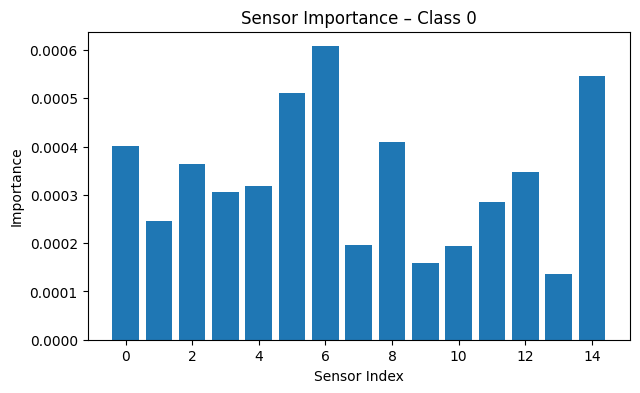

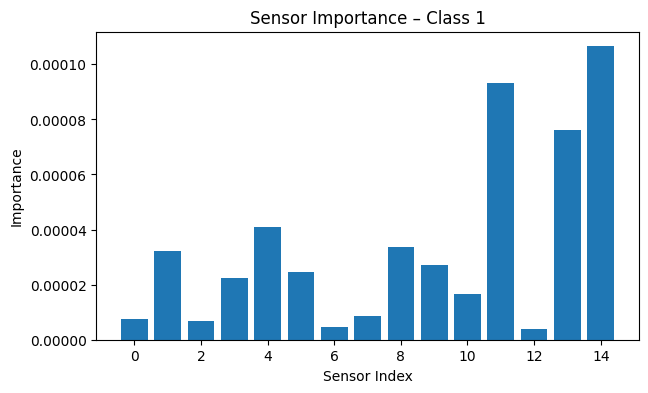

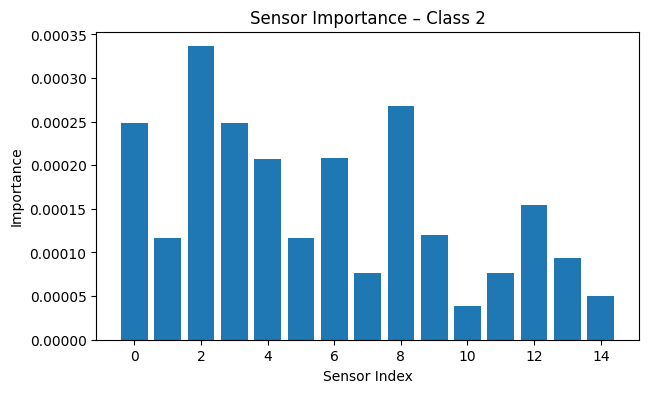

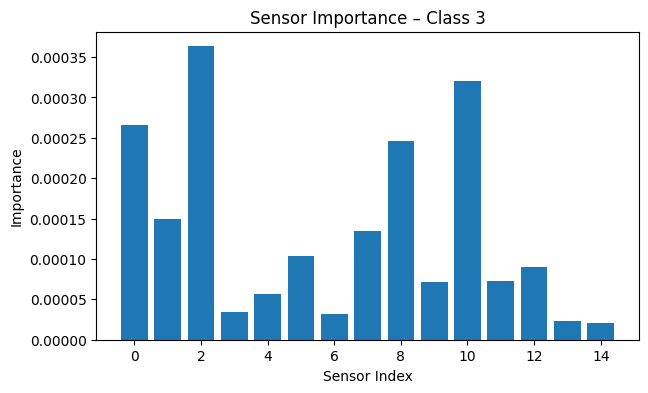

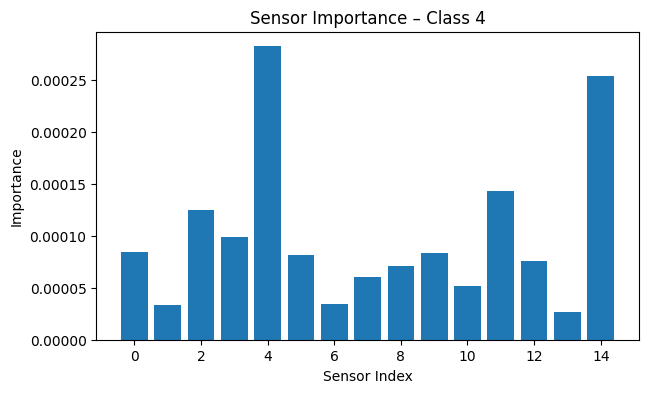

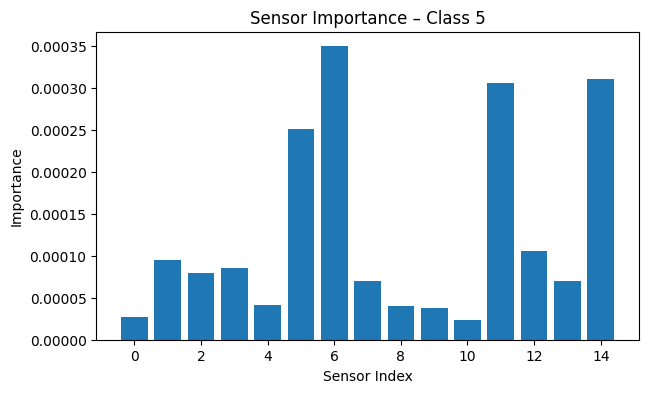

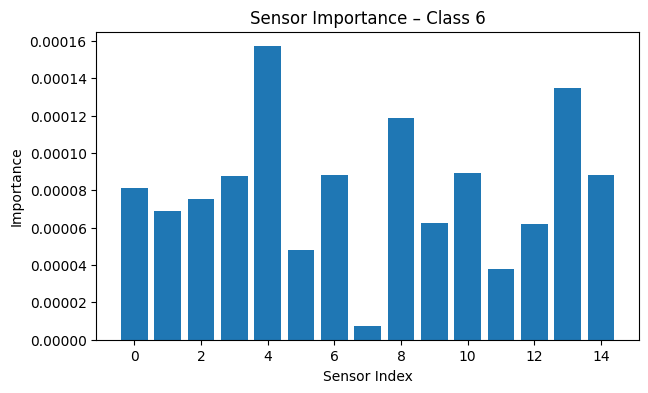

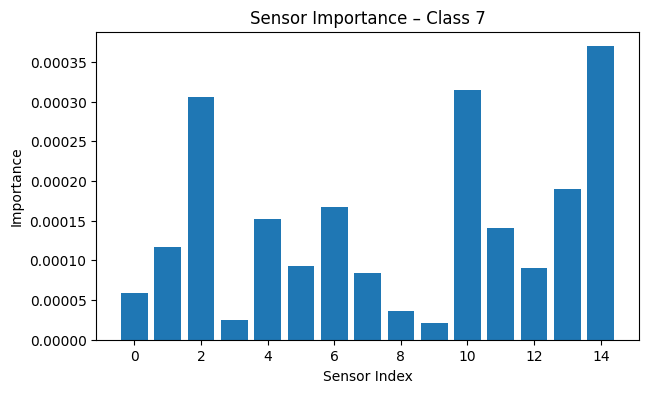

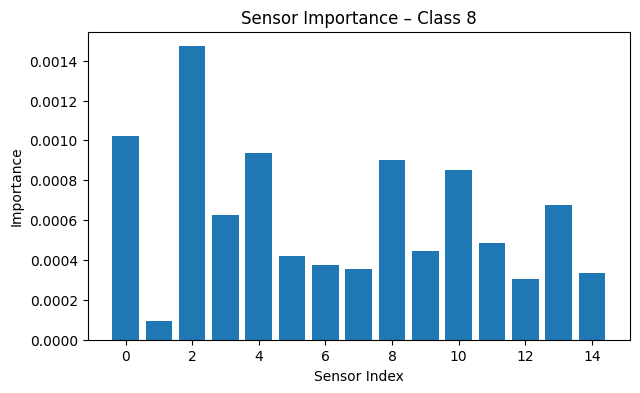

In [ ]:
# =============================================================
# اجرای تابع و محاسبه اهمیت سنسورها برای هر کلاس
# =============================================================
num_classes = 9  # تعداد کلاس‌ها در پروژه تو
importance = compute_feature_importance(model, test_loader, device, num_classes)

print("Importance shape:", importance.shape)
print(importance)

# =============================================================
# رسم نمودار اهمیت سنسورها برای هر کلاس (اختیاری)
# =============================================================
for cls in range(num_classes):
    plt.figure(figsize=(7,4))
    plt.bar(range(importance.shape[1]), importance[cls])
    plt.title(f"Sensor Importance – Class {cls}")
    plt.xlabel("Sensor Index")
    plt.ylabel("Importance")
    plt.show()


In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np
all_pred, all_true = [], []
with torch.no_grad():
    for xb, yb in val_loader:
        out = model(xb.to(device))
        all_pred.append(out.argmax(1).cpu().numpy())
        all_true.append(yb.numpy())
cm = confusion_matrix(np.concatenate(all_true), np.concatenate(all_pred))
print(cm)

[[23  0  0  0  0  0  0  0  0]
 [ 0 23  0  0  0  0  0  0  0]
 [ 0  0 23  0  0  0  0  0  0]
 [ 0  0  0 23  0  0  0  0  0]
 [ 0  0  0  0 23  0  0  0  0]
 [ 0  0  0  0  0 17  0  0  0]
 [ 0  0  0  0  0  0 70  0  0]
 [ 0  0  0  0  0  0  0 70  0]
 [ 0  0  0  0  0  0  0  0 70]]


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, precision_recall_fscore_support

model.eval()
all_true = []
all_pred = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        out = model(xb)
        pred = out.argmax(dim=1).cpu().numpy()
        all_pred.append(pred)
        all_true.append(yb.numpy())

y_true = np.concatenate(all_true)
y_pred = np.concatenate(all_pred)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
print(cm)

# Accuracy
acc = accuracy_score(y_true, y_pred)

# Precision, recall, F1 (macro average over 9 classes)
prec, rec, f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average='macro', zero_division=0
)

print("Accuracy:", acc)
print("Precision (macro):", prec)
print("Recall (macro):", rec)
print("F1 (macro):", f1)


[[23  0  0  0  0  0  0  0  0]
 [ 0 23  0  0  0  0  0  0  0]
 [ 0  0 23  0  0  0  0  0  0]
 [ 0  0  0 23  0  0  0  0  0]
 [ 0  0  0  0 23  0  0  0  0]
 [ 0  0  0  0  0 17  0  0  0]
 [ 0  0  0  0  0  0 70  0  0]
 [ 0  0  0  0  0  0  0 70  0]
 [ 0  0  0  0  0  0  0  0 70]]
Accuracy: 1.0
Precision (macro): 1.0
Recall (macro): 1.0
F1 (macro): 1.0


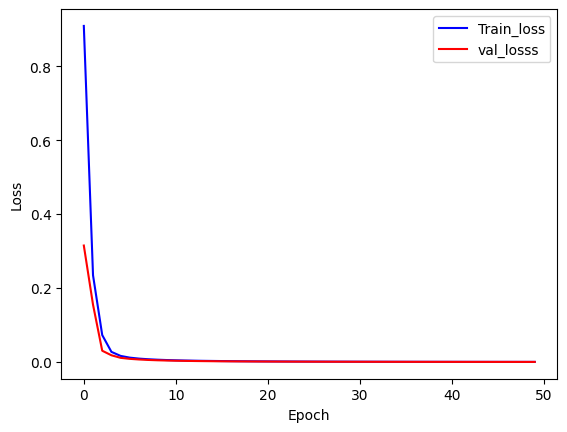

In [ ]:
epoch = np.arange(0,num_epochs , 1)
import matplotlib.pyplot as plt

plt.plot(epoch, tr_losses , label="Train_loss", c='b')
plt.plot(epoch, val_losses, label="val_losss", c='r')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, precision_recall_fscore_support

model.eval()
all_true = []
all_pred = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        out = model(xb)
        pred = out.argmax(dim=1).cpu().numpy()
        all_pred.append(pred)
        all_true.append(yb.numpy())

y_true = np.concatenate(all_true)
y_pred = np.concatenate(all_pred)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
print(cm)

# Accuracy
acc = accuracy_score(y_true, y_pred)

# Precision, recall, F1 (macro average over 9 classes)
prec, rec, f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average='macro', zero_division=0
)

print("Accuracy:", acc)
print("Precision (macro):", prec)
print("Recall (macro):", rec)
print("F1 (macro):", f1)


[[23  0  0  0  0  0  0  0  0]
 [ 0 23  0  0  0  0  0  0  0]
 [ 0  0 23  0  0  0  0  0  0]
 [ 0  0  0 23  0  0  0  0  0]
 [ 0  0  0  0 23  0  0  0  0]
 [ 0  0  0  0  0 17  0  0  0]
 [ 0  0  0  0  0  0 70  0  0]
 [ 0  0  0  0  0  0  0 70  0]
 [ 0  0  0  0  0  0  0  0 70]]
Accuracy: 1.0
Precision (macro): 1.0
Recall (macro): 1.0
F1 (macro): 1.0


In [ ]:
prec_cls, rec_cls, f1_cls, support = precision_recall_fscore_support(
    y_true, y_pred, average=None, zero_division=0
)


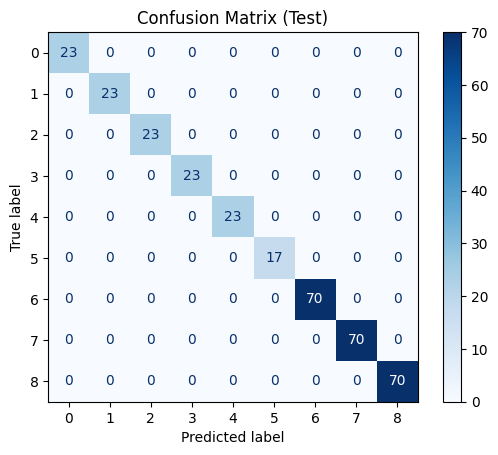

In [ ]:
import torch
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay
import matplotlib.pyplot as plt

y_true, y_pred, y_score = [], [], []
model.eval()

with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device).long()   # targets should be int for CE
        logits = model(xb)                             # [B, num_classes]

        # 1) Probability of class 1
        # For multiclass ROC/PR, you'd typically get scores for each class
        probs  = torch.softmax(logits, dim=1)          # [B, num_classes]
        # y_score is currently only storing probabilities for class 1
        # To plot multiclass ROC/PR, you'd need probabilities for all classes
        # and adapt the plotting functions or use a one-vs-rest approach.
        score1 = probs[:, 1]                           # [B]

        # 2) Predicted class index
        preds  = logits.argmax(dim=1)                  # [B]

        # Save results
        y_true.extend(yb.cpu().tolist())
        y_pred.extend(preds.cpu().tolist())
        y_score.extend(probs.cpu().numpy())
from sklearn.preprocessing import label_binarize
# 1) Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_true, y_pred, cmap="Blues", values_format="d")
plt.title("Confusion Matrix (Test)")
plt.show()

# The following lines are commented out because they are designed for binary classification
# and will raise a ValueError for multiclass targets (0, 1, 2).
# To plot ROC or Precision-Recall for multiclass, a one-vs-rest strategy is typically used,
# which would involve binarizing y_true for each class and providing corresponding class probabilities.

# # 2) ROC
# RocCurveDisplay.from_predictions(y_true, y_score)
# plt.title("ROC Curve (Validation)")
# plt.show()

# # 3) Precision–Recall
# PrecisionRecallDisplay.from_predictions(y_true, y_score)
# plt.title("Precision–Recall Curve (Validation)")
# plt.show()

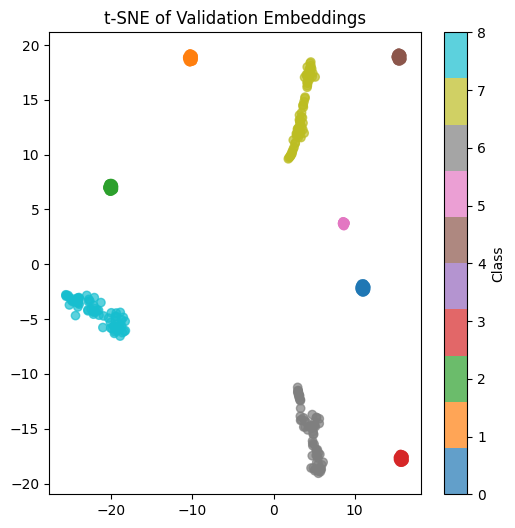

In [ ]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

model.eval()
all_embeds, all_labels = [], []

with torch.no_grad():
    for xb, yb in val_loader:

        xb = xb.to(device)

        x = model.inp(xb)
        x = model.pos(x)
        x = model.encoder(x)

        embeds = x.mean(dim=1)

        all_embeds.append(embeds.cpu())
        all_labels.append(yb)

all_embeds = torch.cat(all_embeds).numpy()
all_labels = torch.cat(all_labels).numpy()

# scaling
all_embeds = StandardScaler().fit_transform(all_embeds)

# t-SNE
tsne = TSNE(n_components=2, perplexity=30, init="pca", random_state=42)
X_2d = tsne.fit_transform(all_embeds)

plt.figure(figsize=(6,6))
plt.scatter(X_2d[:,0], X_2d[:,1], c=all_labels, cmap="tab10", alpha=0.7)
plt.colorbar(label="Class")
plt.title("t-SNE of Validation Embeddings")
plt.show()
